# Error propagation
Irgendwo hier muss ein fehler drin sein
$$
\begin{aligned}
f &\propto \frac{1}{K(\beta)}, K(\beta) = \ln\frac{1+\beta}{1-\beta}, \beta=\frac{R_1}{R_1+R_2}\in (0,1) \\
\frac{\partial f}{\partial \beta} &= \frac{K'(\beta)}{K(\beta)^2} = \frac{-2}{(\beta^2-1)\ln^2\left(\frac{1+\beta}{1-\beta}\right)} \\
\frac{\delta f}{f} &= \left|\frac{K'(\beta)}{K(\beta)}\right| \delta \beta  \\
&=\frac{2}{(1-\beta^2)\ln\left(\frac{1+\beta}{1-\beta}\right)} \delta \beta \\
\beta &= \frac{R_1}{R_1+R_2} \Rightarrow \frac{\partial \beta}{\partial R_1} = \frac{R_2}{(R_1+R_2)^2}, \frac{\partial \beta}{\partial R_2} = \frac{-R_1}{(R_1+R_2)^2} \\
& \Rightarrow \delta \beta \approx \varepsilon \left(\frac{R_1+R_2}{(R_1+R_2)^2}\right) = \frac{\varepsilon}{R_1+R_2} \ \ \ \text{(worst case)}\\
&\Rightarrow \frac{\delta f}{f} = \frac{2\varepsilon}{(R_1+R_2)(1-\beta^2)\ln\frac{1+\beta}{1-\beta}}
\end{aligned}
$$

$\frac{\delta f}{f} \propto \frac{1}{R_1+R_2}$ -> Error propagation wird geringer für größere Widerstände bei konstantem $\beta$

Für $\beta \rightarrow 1$ gilt $\frac{\delta f}{f} = \mathcal{O}\left(\frac{1}{(1-\beta)|ln(1-\beta)|}\right)$, für $\beta \rightarrow 0$ gilt $\frac{\delta f}{f} = \mathcal{O}\left(\frac{1}{\beta}\right)$

$\Rightarrow$ fehler wird scheller größer bei größeren $\beta$ als bei kleineren.

# Wertetabelle
Jeweils $\varepsilon=5%$
| $\beta$ | Pot | $R_C$ | $C_1$ | $C_2$ | $C_3$ | $f_0$ | $f_1$ | $f_2$ | $f_0$ | $\frac{\delta f}{f}$ bei $R_1+R_2 = 1k$ | $\frac{\delta f}{f}$ bei $R_1+R_2 = 100k$ |
| ------- | --- | ----- | ----- | ----- | ----- | ----- | ----- | ----- | ----- | --------------------------------------- | ----------------------------------------- |
| 0.5 | A1M | 33k | 2n | 68n | 2u2| 0.2 | 6.2/6.2 | 219/220 | 6.8k | $0.012\%$ | $0.00012\%$ |
| 0.5 | B50k | 2k | 47n | 1u | 47u | 0.18 | 4.8/9.3 | 217/186 | 4.8k | $0.012\%$ | $0.00012\%$ |
| 0.5 | B100k | 3k3 | 22n | 220n+470n | 22u | 0.38 | 6.2/12 | 193-308 | 6k.3k | $0.012\%$ | $0.00012\%$ |
| 0.5 | B250k | 8k2 | 8n2 | 220n | 10u | 0.17 | 5.5/7.7 | 243/214 | 6.7k | $0.012\%$ | $0.00012\%$ | 

Best solution
C1=8.439e-09 F (8438.9 pF)
C2=2.649e-07 F (264.95 nF)
C3=8.848e-06 F (8.85 µF)
Rc=7931.0 Ω, Rf=250000.0 Ω
K=1.098612
alpha=1.001938
log-MSE=3.748766e-06

eq   target      achieved    error_%
1   0.2         0.199613    -0.19
2   6.47922     6.49178     +0.19
3   6.47922     6.46669     -0.19
4   209.902     210.308     +0.19
5   209.902     209.496     -0.19
6   6800        6813.18     +0.19


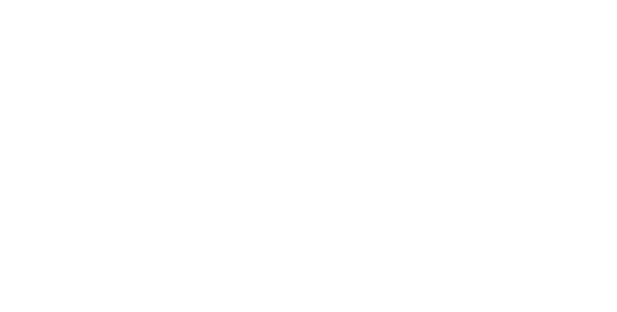

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

base = np.geomspace(0.2, 6800, 4)
targets = np.array([base[0], base[1], base[1], base[2], base[2], base[3]])

Rf_values = np.array([250e3]) 
Rc_values = np.logspace(3, 5, 150) 
K_fixed = np.log(3)
use_fixed_K = True 

K_values = [K_fixed] if use_fixed_K else np.linspace(np.log(2), np.log(9), 10)

def compute_capacitors(Rc, Rf, K):
    fmax1, fmax2, fmax3 = targets[1], targets[3], targets[5]
    Crange1 = 1.0 / (2 * K * Rc * fmax1)
    Crange2 = 1.0 / (2 * K * Rc * fmax2)
    Crange3 = 1.0 / (2 * K * Rc * fmax3)
    C1 = Crange3
    C2 = Crange2 - C1
    C3 = Crange1 - C1
    if C2 <= 0 or C3 <= 0:
        return None, None, None
    return C1, C2, C3

def run():
    total = len(Rf_values) * len(Rc_values) * len(K_values)
    progress = widgets.IntProgress(value=0, min=0, max=total, description="Search")
    status = widgets.HTML(value="")
    chart_out = widgets.Output()
    display(widgets.VBox([progress, status, chart_out]))

    best_err = np.inf
    best_solution = None
    history = []
    step = 0

    for Rf in Rf_values:
        for Rc in Rc_values:
            for K in K_values:
                C1, C2, C3 = compute_capacitors(Rc, Rf, K)
                if C1 is None:
                    step += 1
                    progress.value = step
                    continue

                cap_terms = np.array([C1+C3, C1+C3, C1+C2, C1+C2, C1, C1])
                R_terms = np.array([Rc+Rf, Rc, Rc+Rf, Rc, Rc+Rf, Rc])
                denom = 2 * K * cap_terms * R_terms
                vals = 1.0 / denom

                log_vals = np.log(vals)
                log_targets = np.log(targets)
                alpha = np.exp(np.mean(log_targets - log_vals))
                vals_scaled = vals * alpha
                err = np.mean((np.log(vals_scaled) - log_targets) ** 2)

                if err < best_err:
                    best_err = err
                    best_solution = (C1, C2, C3, Rc, Rf, K, alpha)

                step += 1
                progress.value = step
                history.append(best_err)

                status.value = f"<b>Step:</b> {step} / {total} | <b>Best log-MSE:</b> {best_err:.3e}"

                if step % 20 == 0 or step == total:
                    with chart_out:
                        clear_output(wait=True)
                        plt.figure(figsize=(7,3))
                        plt.semilogy(history)
                        plt.xlabel("Step")
                        plt.ylabel("Best log-MSE")
                        plt.title("Convergence")
                        plt.grid(True, alpha=0.3)
                        plt.show()

    C1b, C2b, C3b, Rcb, Rfb, Kb, alphab = best_solution

    cap_terms = np.array([C1b+C3b, C1b+C3b, C1b+C2b, C1b+C2b, C1b, C1b])
    R_terms = np.array([Rcb+Rfb, Rcb, Rcb+Rfb, Rcb, Rcb+Rfb, Rcb])
    denom = 2 * Kb * cap_terms * R_terms
    vals = (1.0 / denom) * alphab

    print("Best solution")
    print(f"C1={C1b:.3e} F ({C1b*1e12:.1f} pF)")
    print(f"C2={C2b:.3e} F ({C2b*1e9:.2f} nF)")
    print(f"C3={C3b:.3e} F ({C3b*1e6:.2f} µF)")
    print(f"Rc={Rcb:.1f} Ω, Rf={Rfb:.1f} Ω")
    print(f"K={Kb:.6f}")
    print(f"alpha={alphab:.6f}")
    print(f"log-MSE={best_err:.6e}\n")

    print("eq   target      achieved    error_%")
    for i, (t, v) in enumerate(zip(targets, vals), 1):
        e = 100 * (v - t) / t
        print(f"{i:<4}{t:<12.6g}{v:<12.6g}{e:+.2f}")

    plt.figure(figsize=(7,3.2))
    x = np.arange(len(targets))
    w = 0.38
    plt.bar(x - w/2, targets, width=w, label="Target")
    plt.bar(x + w/2, vals, width=w, label="Achieved")
    plt.yscale("log")
    plt.xticks(x, ["fmin1","fmax1","fmin2","fmax2","fmin3","fmax3"])
    plt.ylabel("Frequency (Hz)")
    plt.title("Target vs Achieved")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.show()

run()